In [9]:
import healpy as hp
import matplotlib.pylab as plt
%matplotlib inline
from by_count_utils import FootprintCount, FootprintCountBasisFunction
from rubin_scheduler.scheduler.utils import (
    CurrentAreaMap,
    Footprint,)
import numpy as np
from rubin_scheduler.scheduler.features import Conditions

In [6]:
nside = 32
# Generate footprint over the sky
sky = CurrentAreaMap(nside=nside)
footprints_hp_array, labels = sky.return_maps()

In [7]:

survey_start_mjd=6500
sun_ra_start=0.

template_fp = FootprintCount(survey_start_mjd, sun_ra_start, nside=nside)
for key in footprints_hp_array.dtype.names:
    tmp_fp = np.where(footprints_hp_array[key] > 0, 1, np.nan)
    template_fp.set_footprint(key, tmp_fp)


In [10]:
bf = FootprintCountBasisFunction(footprint=template_fp)

In [11]:
conditions = Conditions()
conditions.mjd = survey_start_mjd

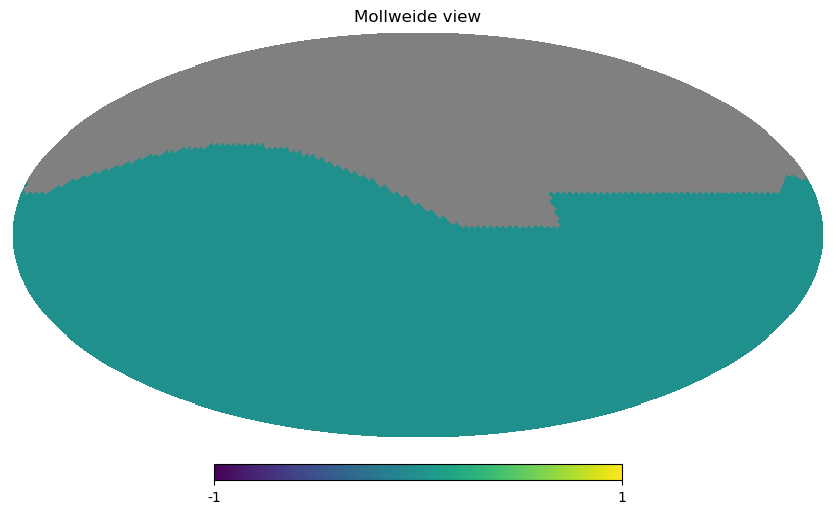

In [13]:
hp.mollview(bf(conditions))

/Users/yoachim/git_repos/rubin_scheduler/rubin_scheduler/scheduler/features/conditions.py:486: UserWarning: Changing MJD and resetting all attributes.
  warnings.warn("Changing MJD and resetting all attributes.")


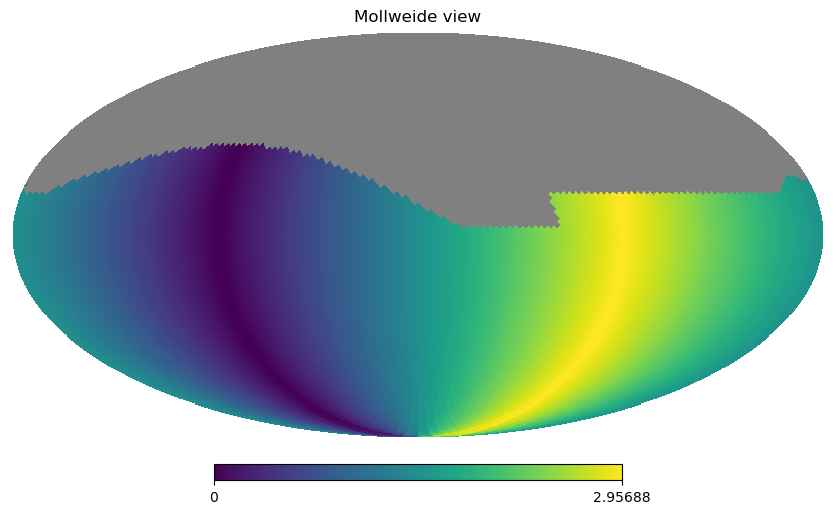

In [14]:
conditions.mjd = survey_start_mjd + 180
hp.mollview(bf(conditions))

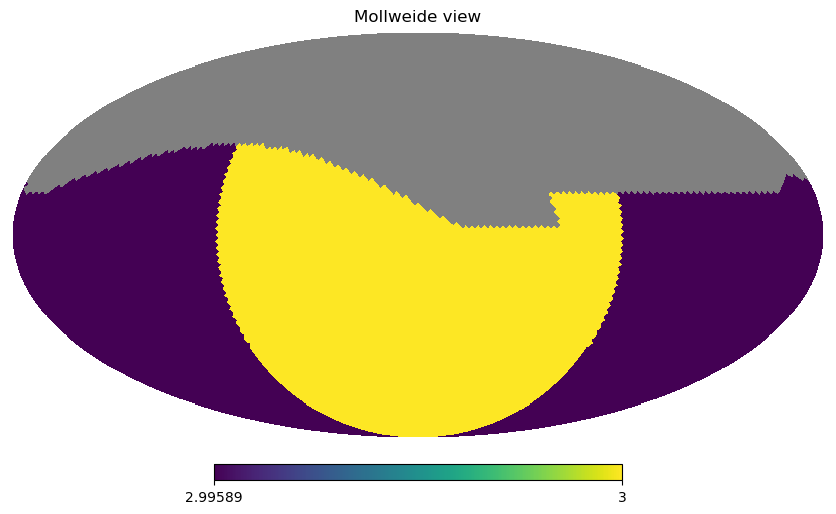

In [18]:
conditions.mjd = survey_start_mjd + 365
hp.mollview(bf(conditions))

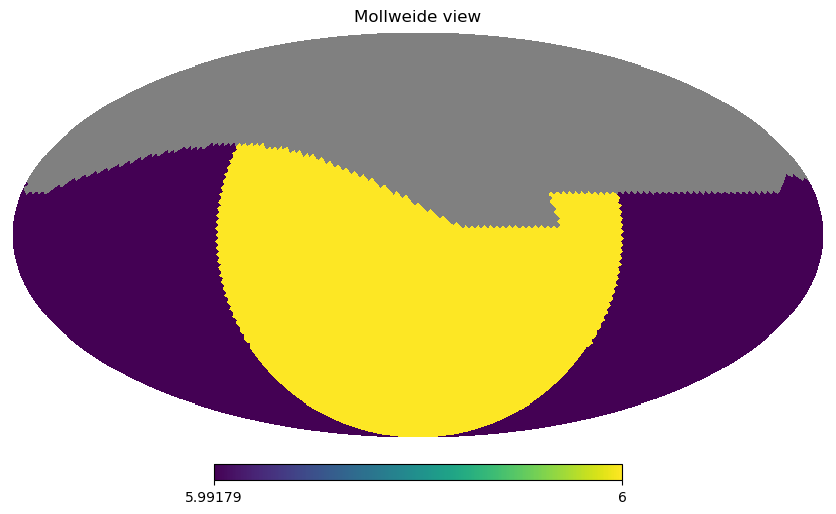

In [19]:
conditions.mjd = survey_start_mjd + 730
hp.mollview(bf(conditions))